# 04 - Explainability

Este notebook analisa a interpretabilidade do melhor modelo salvo em `models/credit_risk_model.pkl`. Em risco de crédito, explicabilidade não é um detalhe visual: ela ajuda a entender se o modelo está usando sinais plausíveis, se há variáveis sensíveis ou proxies preocupantes e quais limitações precisam ser documentadas antes de qualquer uso prático.

A abordagem principal é SHAP. Caso o SHAP fique incompatível ou pesado para o modelo salvo, o notebook usa uma alternativa segura baseada em importância de variáveis do modelo ou permutation importance.

## 1. Imports e configurações

As figuras principais serão salvas em `reports/figures` com nomes fixos para facilitar o uso no README e no relatório final.

In [1]:
import sys
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, Markdown, display
from sklearn.inspection import permutation_importance

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.features.build_features import build_features, split_features_target  # noqa: E402, I001
from src.utils.config import DEFAULT_MODEL_PATH, DEFAULT_PROCESSED_DATA_PATH, FIGURES_DIR, TARGET_COLUMN  # noqa: E402, I001

pd.set_option("display.max_columns", 120)
pd.set_option("display.float_format", "{:.4f}".format)
warnings.filterwarnings("ignore", category=UserWarning)

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
RANDOM_STATE = 42
SAMPLE_SIZE = 300

## 2. Carregar modelo e dados

O artefato salvo pelo treino contém o pipeline completo: pré-processamento e modelo. Para explicar o estimador, carrego uma amostra do dataset processado, recrio as features financeiras e uso o mesmo pipeline treinado.

In [2]:
if not DEFAULT_MODEL_PATH.exists():
    raise FileNotFoundError(
        f"Model artifact not found at {DEFAULT_MODEL_PATH}. "
        "Run: python src/models/train_model.py --sample-size 5000"
    )

if not DEFAULT_PROCESSED_DATA_PATH.exists():
    raise FileNotFoundError(
        f"Processed dataset not found at {DEFAULT_PROCESSED_DATA_PATH}. "
        "Run: python src/data/make_dataset.py"
    )

artifact = joblib.load(DEFAULT_MODEL_PATH)
pipeline = artifact["pipeline"]
metadata = artifact.get("metadata", {})

df = pd.read_csv(DEFAULT_PROCESSED_DATA_PATH)
df = build_features(df)
X, y = split_features_target(df, TARGET_COLUMN)

X_sample = X.sample(min(SAMPLE_SIZE, len(X)), random_state=RANDOM_STATE)
y_sample = y.loc[X_sample.index]

print(f"Modelo carregado: {metadata.get('best_model', 'sem metadados')}")
print(f"Amostra usada para explicabilidade: {len(X_sample):,} linhas")

Modelo carregado: lightgbm
Amostra usada para explicabilidade: 300 linhas


## 3. Preparar matriz transformada

Como o pipeline aplica imputação, escala e one-hot encoding, as explicações globais são calculadas sobre a matriz transformada. Isso significa que algumas variáveis categóricas aparecem como colunas binárias após o encoding.

In [3]:
preprocessor = pipeline.named_steps["preprocess"]
model = pipeline.named_steps["model"]

X_transformed = preprocessor.transform(X_sample)
feature_names = preprocessor.get_feature_names_out()
X_transformed_df = pd.DataFrame(X_transformed, columns=feature_names, index=X_sample.index)

print(f"Matriz transformada: {X_transformed_df.shape[0]:,} linhas x {X_transformed_df.shape[1]:,} colunas")
display(X_transformed_df.head())

Matriz transformada: 300 linhas x 229 colunas


,numeric__SK_ID_CURR,numeric__CNT_CHILDREN,numeric__AMT_INCOME_TOTAL,numeric__AMT_CREDIT,numeric__AMT_ANNUITY,numeric__AMT_GOODS_PRICE,numeric__REGION_POPULATION_RELATIVE,numeric__DAYS_BIRTH,numeric__DAYS_EMPLOYED,numeric__DAYS_REGISTRATION,numeric__DAYS_ID_PUBLISH,numeric__FLAG_MOBIL,numeric__FLAG_EMP_PHONE,numeric__FLAG_WORK_PHONE,numeric__FLAG_CONT_MOBILE,numeric__FLAG_PHONE,numeric__FLAG_EMAIL,numeric__CNT_FAM_MEMBERS,numeric__REGION_RATING_CLIENT,numeric__REGION_RATING_CLIENT_W_CITY,numeric__HOUR_APPR_PROCESS_START,numeric__REG_REGION_NOT_LIVE_REGION,numeric__REG_REGION_NOT_WORK_REGION,numeric__LIVE_REGION_NOT_WORK_REGION,numeric__REG_CITY_NOT_LIVE_CITY,numeric__REG_CITY_NOT_WORK_CITY,numeric__LIVE_CITY_NOT_WORK_CITY,numeric__EXT_SOURCE_1,numeric__EXT_SOURCE_2,numeric__EXT_SOURCE_3,numeric__APARTMENTS_AVG,numeric__BASEMENTAREA_AVG,numeric__YEARS_BEGINEXPLUATATION_AVG,numeric__ELEVATORS_AVG,numeric__ENTRANCES_AVG,numeric__FLOORSMAX_AVG,numeric__LANDAREA_AVG,numeric__LIVINGAREA_AVG,numeric__NONLIVINGAREA_AVG,numeric__APARTMENTS_MODE,numeric__BASEMENTAREA_MODE,numeric__YEARS_BEGINEXPLUATATION_MODE,numeric__ELEVATORS_MODE,numeric__ENTRANCES_MODE,numeric__FLOORSMAX_MODE,numeric__LANDAREA_MODE,numeric__LIVINGAREA_MODE,numeric__NONLIVINGAREA_MODE,numeric__APARTMENTS_MEDI,numeric__BASEMENTAREA_MEDI,numeric__YEARS_BEGINEXPLUATATION_MEDI,numeric__ELEVATORS_MEDI,numeric__ENTRANCES_MEDI,numeric__FLOORSMAX_MEDI,numeric__LANDAREA_MEDI,numeric__LIVINGAREA_MEDI,numeric__NONLIVINGAREA_MEDI,numeric__TOTALAREA_MODE,numeric__OBS_30_CNT_SOCIAL_CIRCLE,numeric__DEF_30_CNT_SOCIAL_CIRCLE,...,categorical__ORGANIZATION_TYPE_Emergency,categorical__ORGANIZATION_TYPE_Government,categorical__ORGANIZATION_TYPE_Hotel,categorical__ORGANIZATION_TYPE_Housing,categorical__ORGANIZATION_TYPE_Industry: type 1,categorical__ORGANIZATION_TYPE_Industry: type 10,categorical__ORGANIZATION_TYPE_Industry: type 11,categorical__ORGANIZATION_TYPE_Industry: type 12,categorical__ORGANIZATION_TYPE_Industry: type 13,categorical__ORGANIZATION_TYPE_Industry: type 2,categorical__ORGANIZATION_TYPE_Industry: type 3,categorical__ORGANIZATION_TYPE_Industry: type 4,categorical__ORGANIZATION_TYPE_Industry: type 5,categorical__ORGANIZATION_TYPE_Industry: type 6,categorical__ORGANIZATION_TYPE_Industry: type 7,categorical__ORGANIZATION_TYPE_Industry: type 8,categorical__ORGANIZATION_TYPE_Industry: type 9,categorical__ORGANIZATION_TYPE_Insurance,categorical__ORGANIZATION_TYPE_Kindergarten,categorical__ORGANIZATION_TYPE_Legal Services,categorical__ORGANIZATION_TYPE_Medicine,categorical__ORGANIZATION_TYPE_Military,categorical__ORGANIZATION_TYPE_Mobile,categorical__ORGANIZATION_TYPE_Other,categorical__ORGANIZATION_TYPE_Police,categorical__ORGANIZATION_TYPE_Postal,categorical__ORGANIZATION_TYPE_Realtor,categorical__ORGANIZATION_TYPE_Religion,categorical__ORGANIZATION_TYPE_Restaurant,categorical__ORGANIZATION_TYPE_School,categorical__ORGANIZATION_TYPE_Security,categorical__ORGANIZATION_TYPE_Security Ministries,categorical__ORGANIZATION_TYPE_Self-employed,categorical__ORGANIZATION_TYPE_Services,categorical__ORGANIZATION_TYPE_Telecom,categorical__ORGANIZATION_TYPE_Trade: type 1,categorical__ORGANIZATION_TYPE_Trade: type 2,categorical__ORGANIZATION_TYPE_Trade: type 3,categorical__ORGANIZATION_TYPE_Trade: type 4,categorical__ORGANIZATION_TYPE_Trade: type 5,categorical__ORGANIZATION_TYPE_Trade: type 6,categorical__ORGANIZATION_TYPE_Trade: type 7,categorical__ORGANIZATION_TYPE_Transport: type 1,categorical__ORGANIZATION_TYPE_Transport: type 2,categorical__ORGANIZATION_TYPE_Transport: type 3,categorical__ORGANIZATION_TYPE_Transport: type 4,categorical__ORGANIZATION_TYPE_University,categorical__ORGANIZATION_TYPE_XNA,categorical__HOUSETYPE_MODE_block of flats,categorical__HOUSETYPE_MODE_specific housing,categorical__HOUSETYPE_MODE_terraced house,categorical__WALLSMATERIAL_MODE_Block,categorical__WALLSMATERIAL_MODE_Mixed,categorical__WALLSMATERIAL_MODE_Monolithic,categorical__WALLSMATERIAL_MODE_Others,c

## 4. Funções auxiliares

A função abaixo tenta gerar SHAP primeiro. Se não funcionar, usa importância nativa de modelos de árvore. Se o modelo salvo não expuser `feature_importances_`, usa permutation importance no pipeline completo.

In [4]:
def select_positive_class_shap_values(shap_values):
    if isinstance(shap_values, list):
        return shap_values[1] if len(shap_values) > 1 else shap_values[0]

    values = getattr(shap_values, "values", shap_values)
    values = np.asarray(values)

    if values.ndim == 3:
        return values[:, :, 1] if values.shape[2] > 1 else values[:, :, 0]

    return values


def build_importance_frame(importances: np.ndarray, names: list[str]) -> pd.DataFrame:
    frame = pd.DataFrame(
        {
            "feature": names,
            "importance": importances,
        }
    )
    return frame.sort_values("importance", ascending=False).reset_index(drop=True)


def save_importance_bar_plot(
    importance_frame: pd.DataFrame,
    output_path: Path,
    title: str,
    top_n: int = 20,
) -> None:
    top_features = importance_frame.head(top_n).sort_values("importance")

    fig, ax = plt.subplots(figsize=(9, 7))
    ax.barh(top_features["feature"], top_features["importance"], color="#4C78A8")
    ax.set_title(title)
    ax.set_xlabel("Importance")
    fig.tight_layout()
    fig.savefig(output_path, dpi=150, bbox_inches="tight")
    plt.close(fig)


def explain_with_shap_or_fallback():
    shap_summary_path = FIGURES_DIR / "shap_summary.png"
    shap_bar_path = FIGURES_DIR / "shap_bar.png"

    try:
        import shap

        explainer = shap.TreeExplainer(model)
        shap_values = explainer.shap_values(X_transformed_df)
        positive_shap_values = select_positive_class_shap_values(shap_values)
        mean_abs_shap = np.abs(positive_shap_values).mean(axis=0)
        importance_frame = build_importance_frame(mean_abs_shap, list(feature_names))

        shap.summary_plot(
            positive_shap_values,
            X_transformed_df,
            max_display=20,
            show=False,
        )
        plt.tight_layout()
        plt.savefig(shap_summary_path, dpi=150, bbox_inches="tight")
        plt.close()

        shap.summary_plot(
            positive_shap_values,
            X_transformed_df,
            plot_type="bar",
            max_display=20,
            show=False,
        )
        plt.tight_layout()
        plt.savefig(shap_bar_path, dpi=150, bbox_inches="tight")
        plt.close()

        return "shap", importance_frame, None

    except Exception as exc:
        if hasattr(model, "feature_importances_"):
            importance_frame = build_importance_frame(
                np.asarray(model.feature_importances_),
                list(feature_names),
            )
            method = "model_feature_importance"
        else:
            result = permutation_importance(
                pipeline,
                X_sample,
                y_sample,
                scoring="average_precision",
                n_repeats=5,
                random_state=RANDOM_STATE,
                n_jobs=-1,
            )
            importance_frame = build_importance_frame(
                result.importances_mean,
                list(X_sample.columns),
            )
            method = "permutation_importance"

        save_importance_bar_plot(
            importance_frame,
            shap_summary_path,
            title=f"Fallback importance ({method})",
        )
        save_importance_bar_plot(
            importance_frame,
            shap_bar_path,
            title=f"Fallback importance ({method})",
        )

        return method, importance_frame, exc

## 5. Gerar explicações globais

A tabela abaixo mostra as variáveis mais importantes de acordo com o método disponível nesta execução. Quando SHAP é usado, a importância é a média do valor absoluto de SHAP na amostra.

In [5]:
explainability_method, importance_frame, fallback_error = explain_with_shap_or_fallback()

print(f"Método usado: {explainability_method}")
if fallback_error is not None:
    print(f"SHAP não foi usado nesta execução porque ocorreu: {type(fallback_error).__name__}: {fallback_error}")

display(importance_frame.head(20))

C:\Users\lucas\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Método usado: shap


,feature,importance
0,numeric__EXT_SOURCE_3,0.3567
1,numeric__EXT_SOURCE_2,0.3502
2,numeric__EXT_SOURCE_1,0.1625
3,numeric__CREDIT_ANNUITY_RATIO,0.1622
4,numeric__AMT_GOODS_PRICE,0.1222
5,numeric__DAYS_BIRTH,0.0867
6,numeric__AMT_ANNUITY,0.0848
7,categorical__NAME_EDUCATION_TYPE_Higher education,0.0795
8,categorical__CODE_GENDER_F,0.0756
9,categorical__FLAG_OWN_CAR_N,0.0750


### SHAP summary / fallback summary

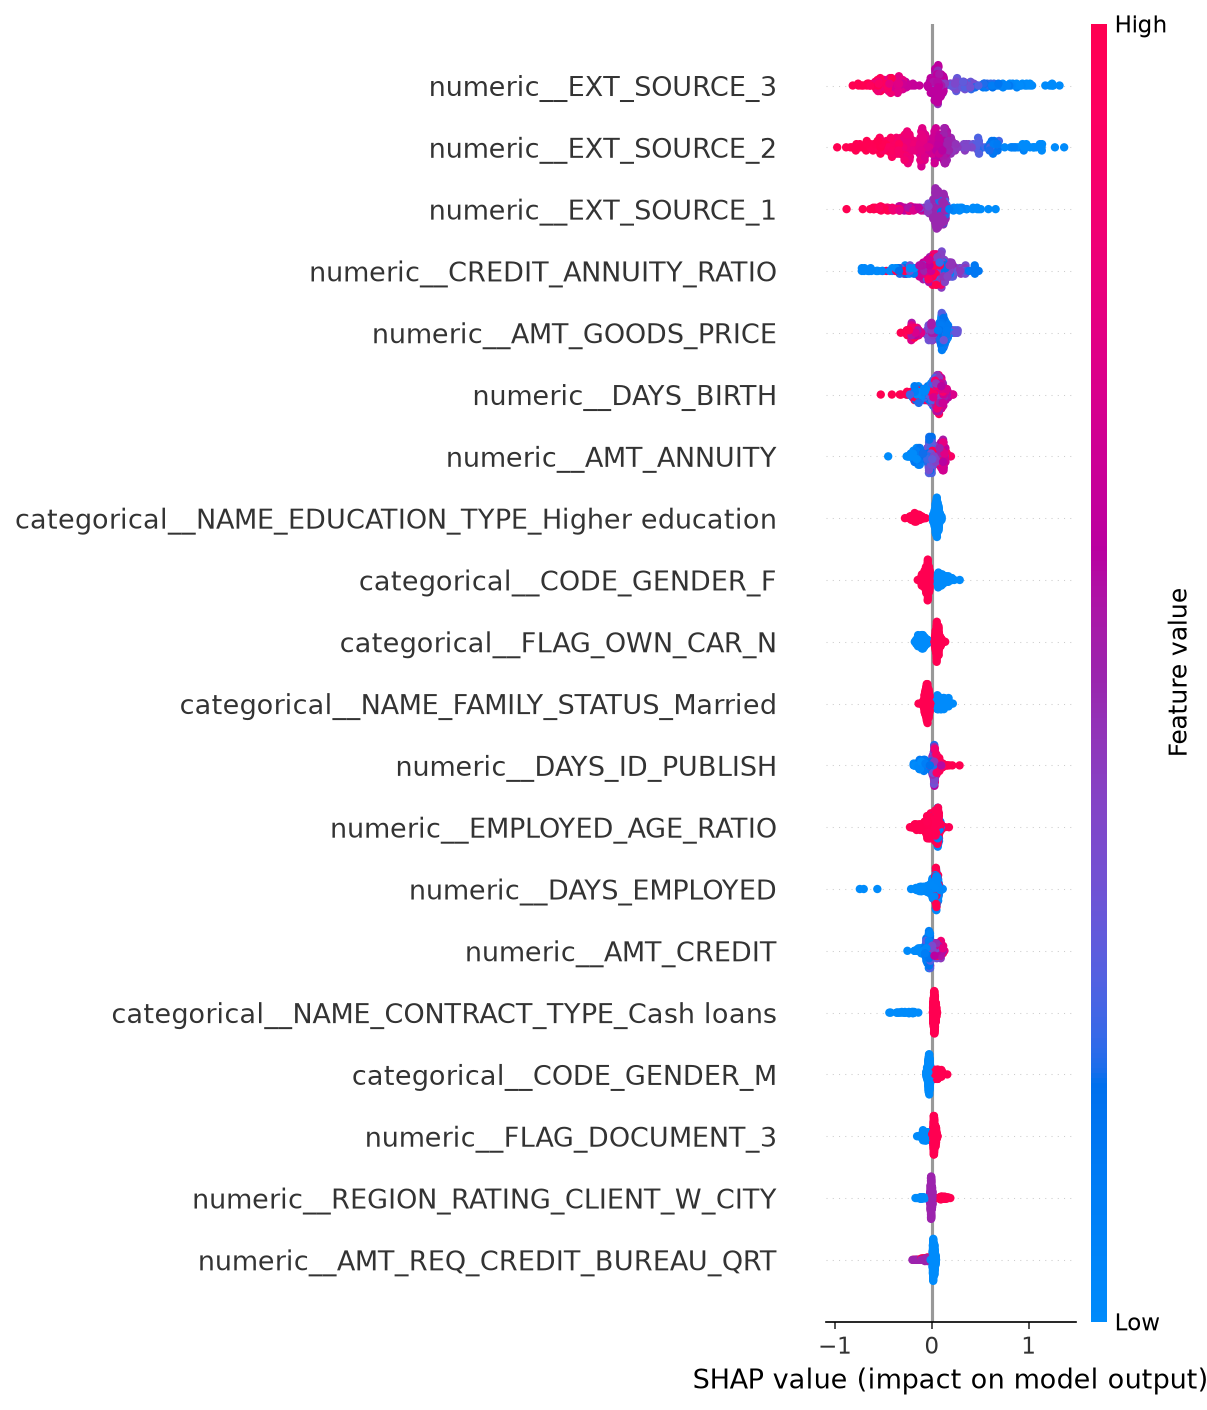

### SHAP bar / fallback bar

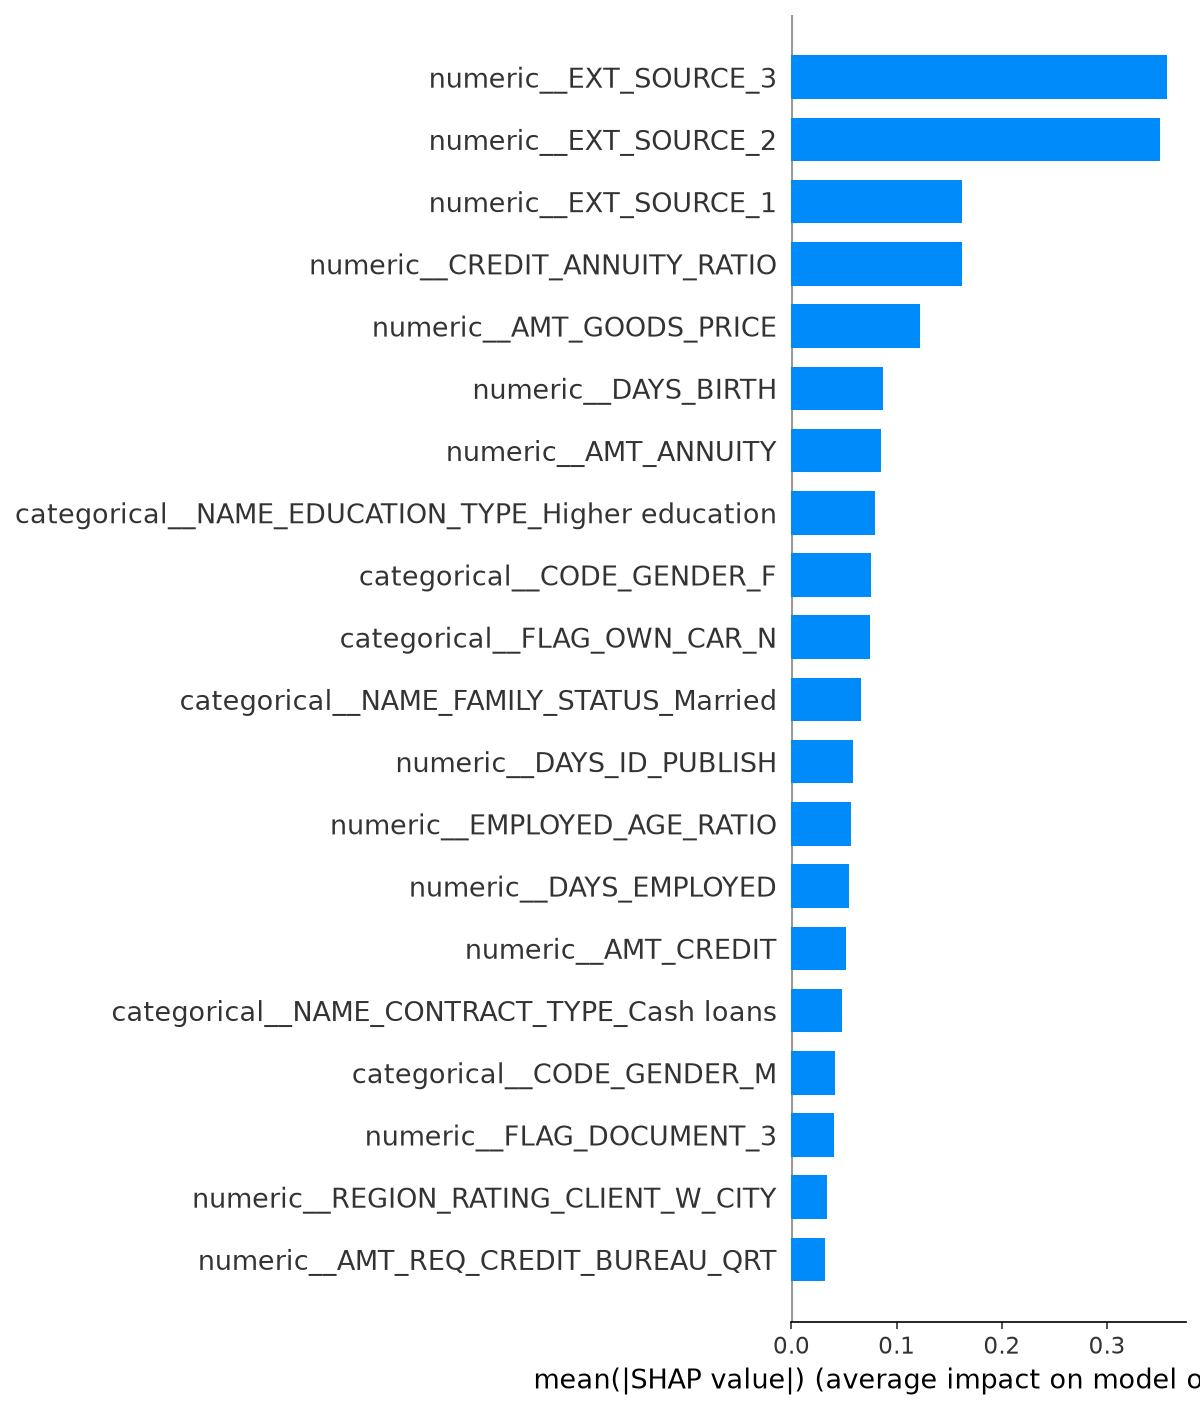

In [6]:
for title, path in {
    "SHAP summary / fallback summary": FIGURES_DIR / "shap_summary.png",
    "SHAP bar / fallback bar": FIGURES_DIR / "shap_bar.png",
}.items():
    if not path.exists():
        raise FileNotFoundError(f"Expected explainability figure not found: {path}")
    display(Markdown(f"### {title}"))
    display(Image(filename=str(path)))

## 6. Interpretação inicial

A leitura abaixo usa as variáveis mais importantes calculadas no notebook. Ela não deve ser tratada como causalidade: o modelo aprende associações nos dados, não regras econômicas definitivas.

In [7]:
top_features = importance_frame.head(10)["feature"].tolist()

notes = [
    f"Método usado nesta execução: **{explainability_method}**.",
    f"As variáveis mais influentes nesta amostra incluem: {', '.join(f'`{feature}`' for feature in top_features[:5])}.",
    "Essas variáveis indicam quais sinais o modelo mais usa para ordenar risco, mas não provam que uma característica causa inadimplência.",
    "Em crédito, explicabilidade importa porque decisões automatizadas podem afetar acesso a produtos financeiros e precisam ser auditáveis.",
    "As principais limitações desta análise são: amostra pequena para explicação, possível correlação entre variáveis, one-hot encoding expandindo categorias e ausência de validação de justiça/fairness nesta etapa.",
]

display(Markdown("\n".join(f"- {note}" for note in notes)))

- Método usado nesta execução: **shap**.
- As variáveis mais influentes nesta amostra incluem: `numeric__EXT_SOURCE_3`, `numeric__EXT_SOURCE_2`, `numeric__EXT_SOURCE_1`, `numeric__CREDIT_ANNUITY_RATIO`, `numeric__AMT_GOODS_PRICE`.
- Essas variáveis indicam quais sinais o modelo mais usa para ordenar risco, mas não provam que uma característica causa inadimplência.
- Em crédito, explicabilidade importa porque decisões automatizadas podem afetar acesso a produtos financeiros e precisam ser auditáveis.
- As principais limitações desta análise são: amostra pequena para explicação, possível correlação entre variáveis, one-hot encoding expandindo categorias e ausência de validação de justiça/fairness nesta etapa.

## 7. Cuidados éticos e limitações

- O modelo não deve ser usado sozinho para aprovar ou negar crédito. Ele é uma ferramenta de apoio analítico.
- Variáveis aparentemente neutras podem funcionar como proxies de renda, região, idade ou outras características sensíveis.
- Explicações globais mostram padrões médios; elas não substituem análise individual cuidadosa.
- Antes de qualquer uso real, seria necessário avaliar fairness, estabilidade temporal, calibração de probabilidade, drift e política de contestação de decisão.
- A base do Kaggle é útil para estudo, mas não representa automaticamente uma carteira atual de crédito.

## Main takeaways

- A explicabilidade ajuda a verificar se o modelo está usando sinais plausíveis e documentáveis.
- SHAP é a opção preferida quando compatível, mas importâncias alternativas mantêm o notebook executável.
- As features mais importantes devem orientar revisão de dados, análise de vazamento e discussão de risco ético antes de qualquer deploy.